# Automobile Sales Recession Analysis Dashboard

## Project Objective

Analyze historical automobile sales data to understand how recession periods affect automobile sales and identify the economic factors influencing sales trends.

## Tools Used

Python, Pandas, Matplotlib, Seaborn, Plotly Dash


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dash import Dash, dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

## Load Dataset

In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

df = pd.read_csv(URL)

df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


## Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2112 non-null   object 
 1   Year                     2112 non-null   int64  
 2   Month                    2112 non-null   object 
 3   Recession                2112 non-null   int64  
 4   Consumer_Confidence      2112 non-null   float64
 5   Seasonality_Weight       2112 non-null   float64
 6   Price                    2112 non-null   int64  
 7   Advertising_Expenditure  2112 non-null   float64
 8   Competition              2112 non-null   int64  
 9   GDP                      2112 non-null   float64
 10  Growth_Rate              2112 non-null   float64
 11  unemployment_rate        2112 non-null   float64
 12  Automobile_Sales         2112 non-null   float64
 13  Vehicle_Type             2112 non-null   object 
 14  City                    

## Data Cleaning

In [4]:
df.isnull().sum()

Date                       0
Year                       0
Month                      0
Recession                  0
Consumer_Confidence        0
Seasonality_Weight         0
Price                      0
Advertising_Expenditure    0
Competition                0
GDP                        0
Growth_Rate                0
unemployment_rate          0
Automobile_Sales           0
Vehicle_Type               0
City                       0
dtype: int64

In [5]:
df = df.drop_duplicates()

## Convert Date Column

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

## Line chart showing automobile sales trend across years.

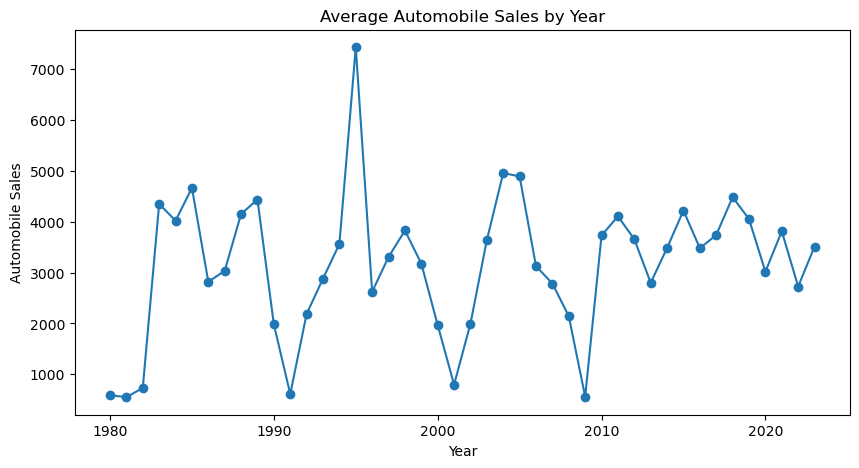

In [7]:
yearly_sales = df.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(10,5))

plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.title("Average Automobile Sales by Year")
plt.xlabel("Year")
plt.ylabel("Automobile Sales")

plt.show()

## Relationship between advertising expenditure and automobile sales during non-recession periods.

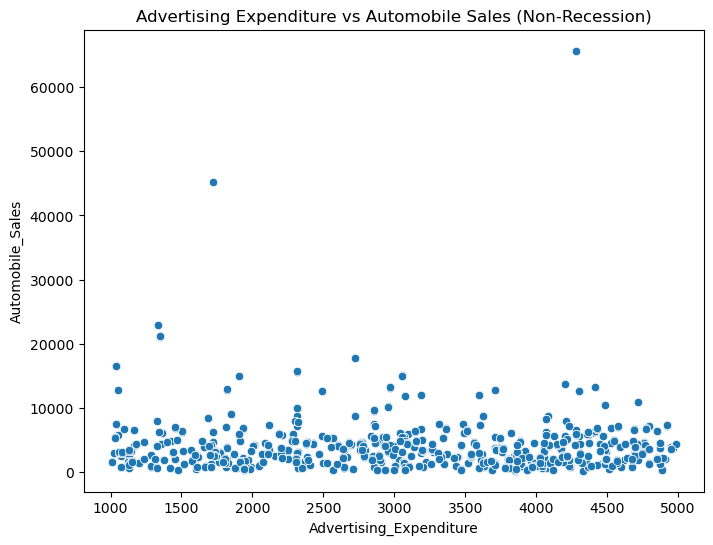

In [8]:
non_recession = df[df['Recession']==0]

plt.figure(figsize=(8,6))

sns.scatterplot(
data=non_recession,
x='Advertising_Expenditure',
y='Automobile_Sales'
)

plt.title("Advertising Expenditure vs Automobile Sales (Non-Recession)")

plt.show()

## Sales trends by vehicle type

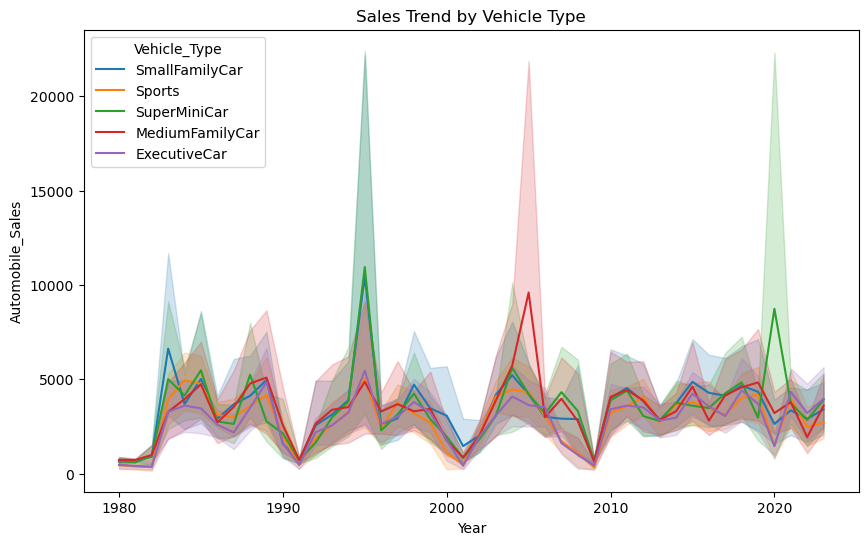

In [9]:
plt.figure(figsize=(10,6))

sns.lineplot(
data=df,
x='Year',
y='Automobile_Sales',
hue='Vehicle_Type'
)

plt.title("Sales Trend by Vehicle Type")

plt.show()

## Compare GDP during recession and non-recession periods.

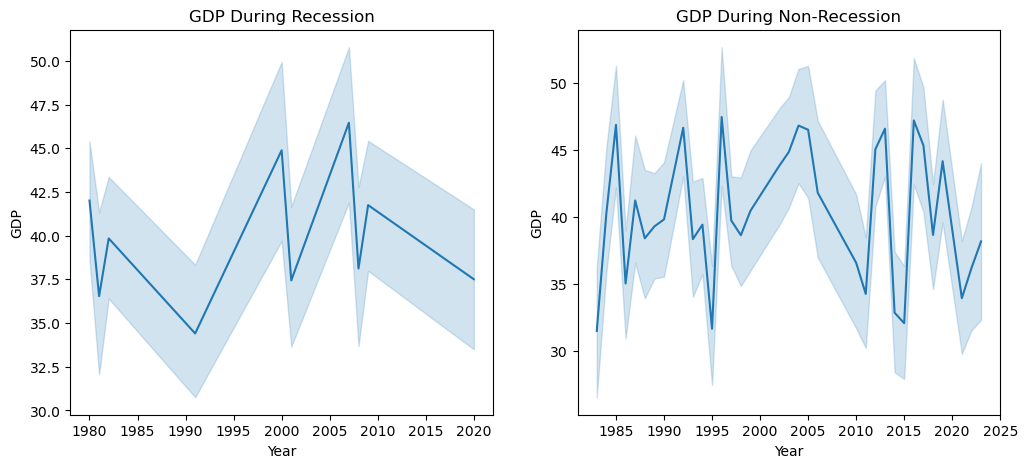

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

recession = df[df['Recession']==1]
non_recession = df[df['Recession']==0]

sns.lineplot(data=recession, x='Year', y='GDP', ax=ax[0])
ax[0].set_title("GDP During Recession")

sns.lineplot(data=non_recession, x='Year', y='GDP', ax=ax[1])
ax[1].set_title("GDP During Non-Recession")

plt.show()

## Bubble plot showing seasonality impact on automobile sales.

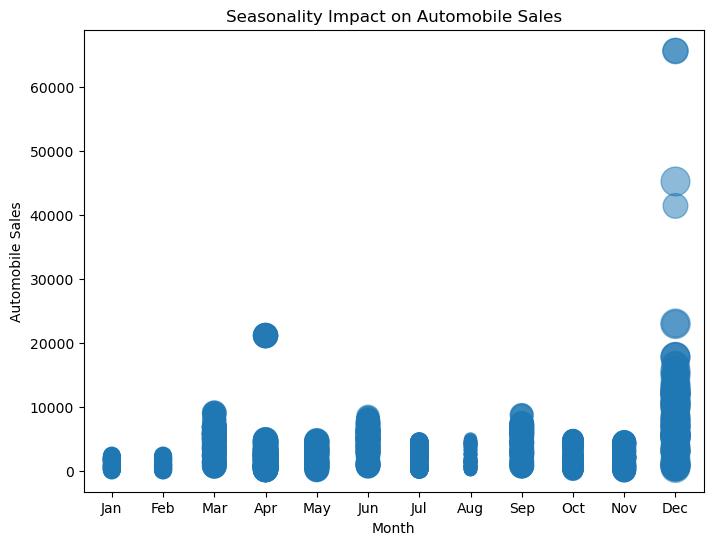

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
df['Month'],
df['Automobile_Sales'],
s=df['Seasonality_Weight']*300,
alpha=0.5
)

plt.xlabel("Month")
plt.ylabel("Automobile Sales")

plt.title("Seasonality Impact on Automobile Sales")

plt.show()

## Scatter plot showing vehicle price vs sales during recession.

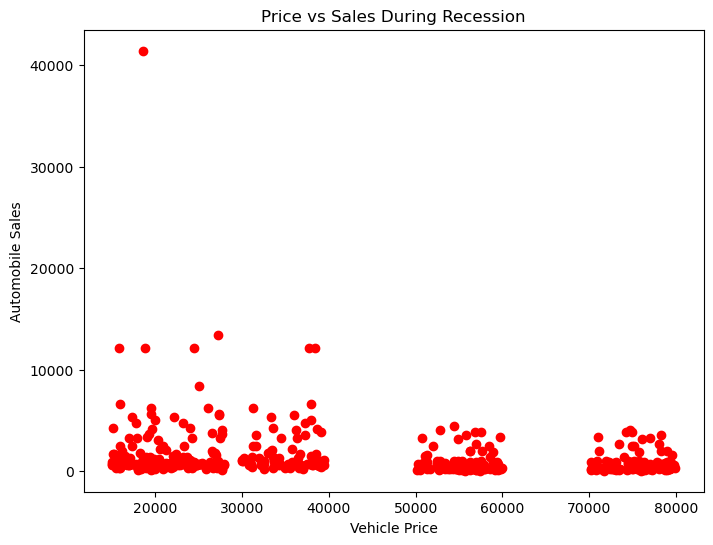

In [12]:
recession = df[df['Recession']==1]

plt.figure(figsize=(8,6))

plt.scatter(
recession['Price'],
recession['Automobile_Sales'],
color='red'
)

plt.xlabel("Vehicle Price")
plt.ylabel("Automobile Sales")

plt.title("Price vs Sales During Recession")

plt.show()

## Pie chart showing advertising expenditure distribution.

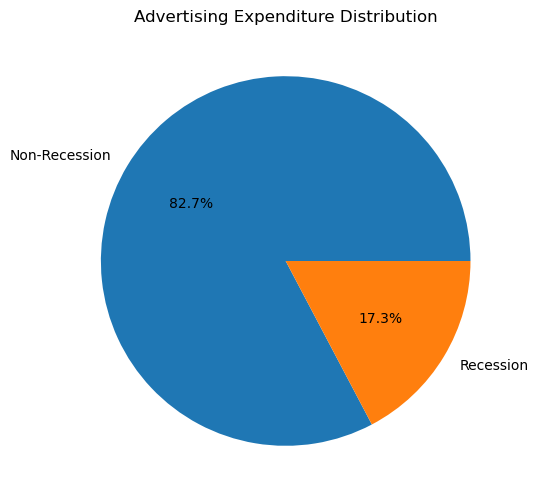

In [13]:
ad_data = df.groupby('Recession')['Advertising_Expenditure'].sum()

labels = ['Non-Recession','Recession']

plt.figure(figsize=(6,6))

plt.pie(ad_data, labels=labels, autopct='%1.1f%%')

plt.title("Advertising Expenditure Distribution")

plt.show()

## Advertisement expenditure by vehicle type during recession.

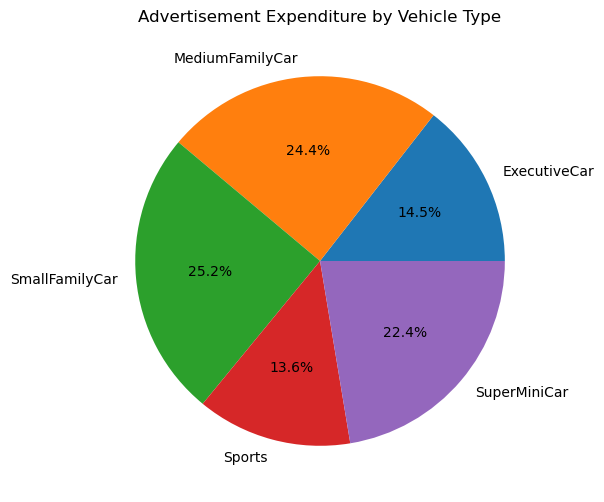

In [14]:
recession = df[df['Recession']==1]

ad_vehicle = recession.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(6,6))

plt.pie(ad_vehicle, labels=ad_vehicle.index, autopct='%1.1f%%')

plt.title("Advertisement Expenditure by Vehicle Type")

plt.show()

## Analyze unemployment rate impact on vehicle sales.

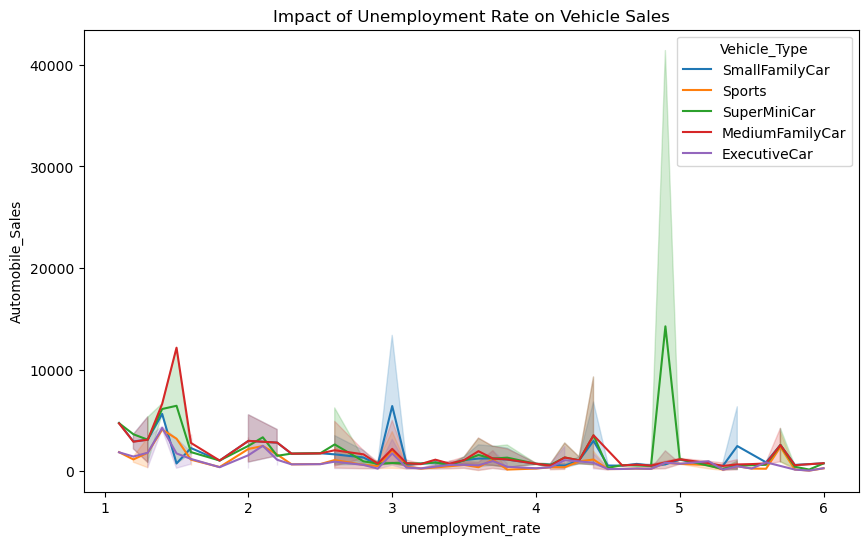

In [15]:
recession = df[df['Recession']==1]

plt.figure(figsize=(10,6))

sns.lineplot(
data=recession,
x='unemployment_rate',
y='Automobile_Sales',
hue='Vehicle_Type'
)

plt.title("Impact of Unemployment Rate on Vehicle Sales")

plt.show()

## Correlation Analysis

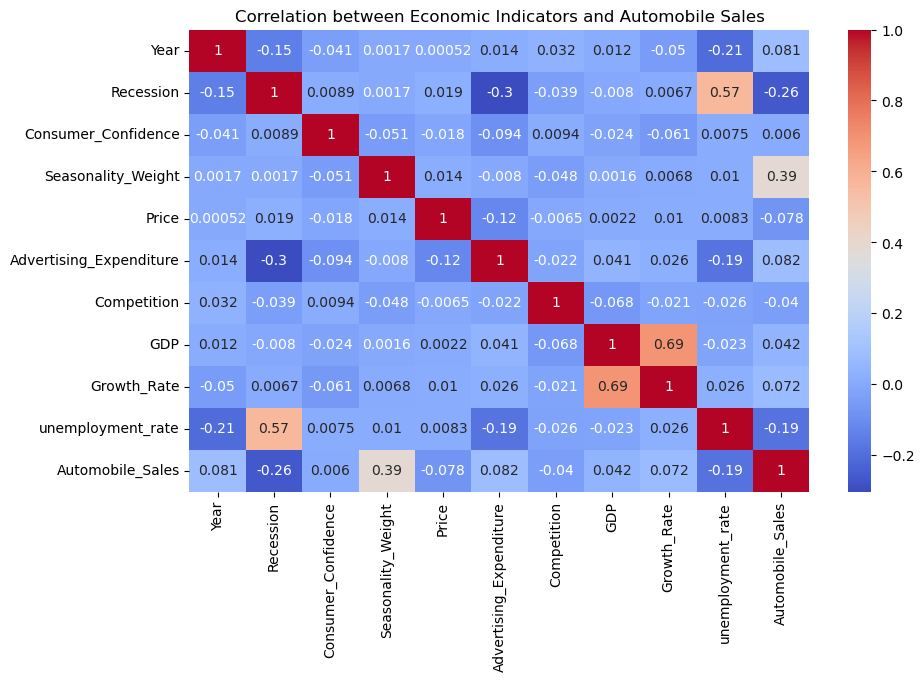

In [56]:
plt.figure(figsize=(10,6))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap='coolwarm'
)

plt.title("Correlation between Economic Indicators and Automobile Sales")

plt.show()

## Sales Distribution During Recession vs Non-Recession

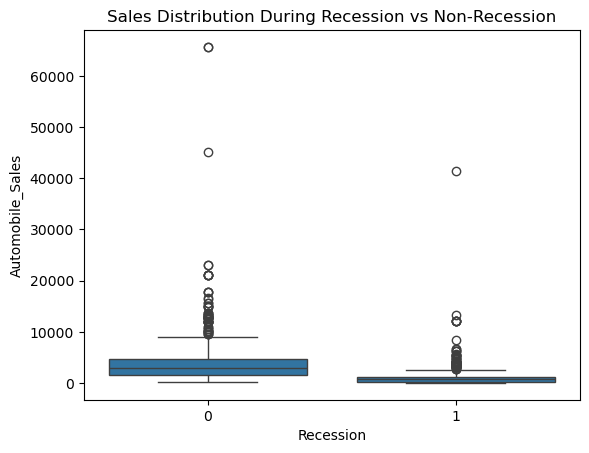

In [57]:
sns.boxplot(
x='Recession',
y='Automobile_Sales',
data=df
)

plt.title("Sales Distribution During Recession vs Non-Recession")

plt.show()

## Vehicle Type Sales Comparison

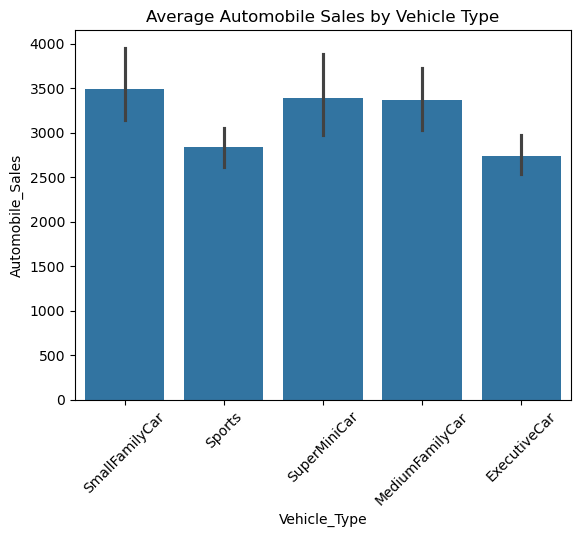

In [58]:
sns.barplot(
x='Vehicle_Type',
y='Automobile_Sales',
data=df
)

plt.title("Average Automobile Sales by Vehicle Type")

plt.xticks(rotation=45)

plt.show()

## Monthly Automobile Sales Trend

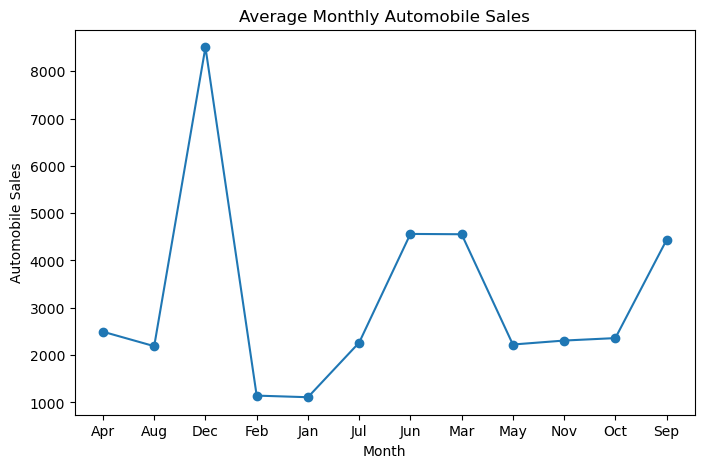

In [59]:
monthly_sales = df.groupby('Month')['Automobile_Sales'].mean()

plt.figure(figsize=(8,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Average Monthly Automobile Sales")

plt.xlabel("Month")
plt.ylabel("Automobile Sales")

plt.show()

## Monthly Automobile Sales Trend

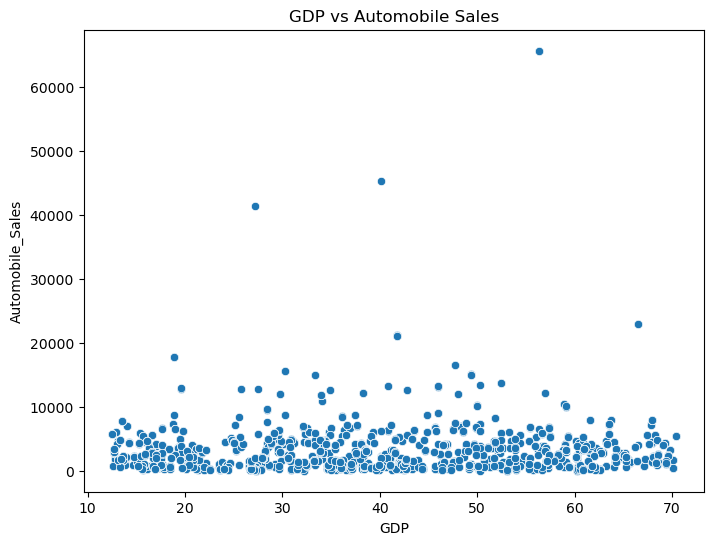

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x='GDP',
y='Automobile_Sales',
data=df
)

plt.title("GDP vs Automobile Sales")

plt.show()